# Handwritten Digit Recognition

Kaggle competition: https://www.kaggle.com/competitions/digit-recognizer/overview

Table of Content
1. [EDA](#eda)
2. [Pytorch](#pytorch)


ref
- https://www.kaggle.com/code/itsmohammadshahid/7-cnn-handwritten-digit-recognition 
- https://www.kaggle.com/code/analyticaobscura/blazing-fast-mnist-with-pytorch-cuda

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sn
import numpy as np 
import pandas as pd
import math
import datetime
import platform

import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./handwritten-digit-recognition.ipynb
./mnist-original.mat
./submission.csv
./model.png
./data/.DS_Store
./data/digit-recognizer.zip
./data/digit-recognizer/test.csv
./data/digit-recognizer/train.csv
./data/digit-recognizer/sample_submission.csv


In [2]:
print('Python version:', platform.python_version())
print('Tensorflow version:', tf.__version__)
print('Keras version:', tf.keras.__version__)

Python version: 3.12.12
Tensorflow version: 2.18.0
Keras version: 3.11.2


# EDA

In [3]:
# Load the TensorBoard notebook extension.
# %reload_ext tensorboard
%load_ext tensorboard

In [4]:
# Clear any logs from previous runs.
!rm -rf ./.logs/

In [5]:
# Unzip the credit card file, load data to dataframe, then delete the large unzipped csv file

# ==========================
# print all files in the current directory
# import os
# for dirname, _, filenames in os.walk('./'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
# ==========================

# Step 1: unzip file
from zipfile import ZipFile
with ZipFile('./data/digit-recognizer.zip', 'r') as zip_object:
    zip_object.extractall('./data/digit-recognizer/')

# ==========================
# (Optional) If file is too large, we can divide it and load them to datafram.
# Step 2.1: Divide the original credit card fraud file (150.8MB, too large to upload to Github) into smaller size 
# import pandas as pd

# input_csv_file_path = './data/credit-card-fraud/creditcard.csv'
# rows_per_file = 50_000
# output_prefix = 'data/credit-card-fraud/creditcard_part_'

# csv_reader = pd.read_csv(input_csv_file_path, chunksize=rows_per_file)
# for i, chunk in enumerate(csv_reader):
#     output_file = f'{output_prefix}{i}.csv'
#     chunk.to_csv(output_file, index=False)
#     print(f'Created {output_file}')

# Step 2.2: Load files into a data frame
# import pandas as pd
# import glob

# path = './data/credit-card-fraud/'
# all_files = glob.glob(path + "creditcard_part_*.csv")

# df_list = []
# for filename in all_files:
#     df = pd.read_csv(filename)
#     df_list.append(df)
# df = pd.concat(df_list, ignore_index=True)
# ==========================

# Step 2: load data to dataframe
import pandas as pd
train = pd.read_csv('./data/digit-recognizer/train.csv')
test = pd.read_csv('./data/digit-recognizer/test.csv')

# Step 3: delete extracted csv files and folder
import os
import shutil
input_csv_folder_path = './data/digit-recognizer'
shutil.rmtree(input_csv_folder_path)

In [6]:
train.shape, test.shape

((42000, 785), (28000, 784))

In [7]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


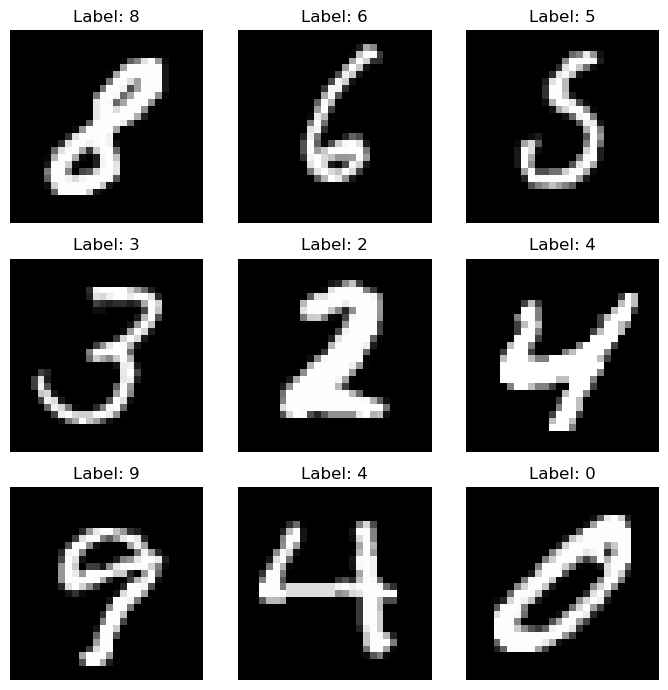

In [8]:
# Plot some random sample images
fig, axes = plt.subplots(3, 3, figsize=(7,7))
axes = axes.ravel()

for i, ax in enumerate(axes):
    random_index = np.random.randint(0, train.shape[0])
    img = train.iloc[random_index, 1:].values.reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {train.iloc[random_index, 0]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
train.info(), train.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


(None, (42000, 785))

In [10]:
X = train.drop('label', axis=1)
y = train['label']

X_test = test.copy()

### Visualize with TSNE

In [11]:
X_tsn = X/255

from sklearn.manifold import TSNE
tsne = TSNE(random_state=42)
tsne_res = tsne.fit_transform(X_tsn)

In [12]:
tsne_res.shape

(42000, 2)

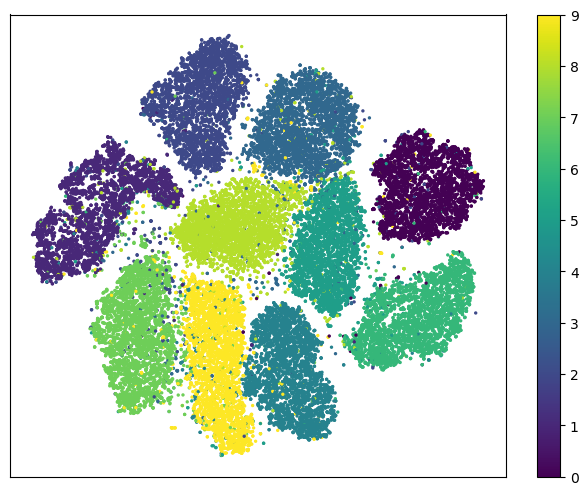

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(tsne_res[:,0], tsne_res[:,1], c=y, s=2)
plt.xticks([])
plt.yticks([])
plt.colorbar();

# PyTorch

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.utils.data
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os
from six.moves import urllib

print("PyTorch version:", torch.__version__)

PyTorch version: 2.6.0
CUDA available: False


In [ ]:
# Check for available devices and set the appropriate device
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using {device} device")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"CUDA available: {torch.cuda.is_available()}")

Using mps device
MPS available: True
CUDA available: False


In [27]:
# Define the path and URL for the MNIST training data
mnist_path = "mnist-original.mat"
mnist_alternative_url = "https://github.com/amplab/datascience-sp14/raw/master/lab7/mldata/mnist-original.mat"

# Download the training dataset if it doesn't exist
if not os.path.exists(mnist_path):
    print("Downloading MNIST training data...")
    response = urllib.request.urlopen(mnist_alternative_url)
    with open(mnist_path, "wb") as f:
        content = response.read()
        f.write(content)
    print("Download complete.")

# Load the .mat file
mnist_raw = loadmat(mnist_path)

# Extract training images (X) and labels (y)
# The data is stored as (features, samples), so we transpose it with .T
X_train = mnist_raw["data"].T
# Use np.int64 instead of the deprecated np.long
y_train = mnist_raw["label"][0].astype(np.int64)

# Get the test images as a numpy array
X_test = test.to_numpy()

print(f"Shape of training data (X_train): {X_train.shape}")
print(f"Shape of training labels (y_train): {y_train.shape}")
print(f"Shape of test data (X_test):     {X_test.shape}")

Shape of training data (X_train): (70000, 784)
Shape of training labels (y_train): (70000,)
Shape of test data (X_test):     (28000, 784)


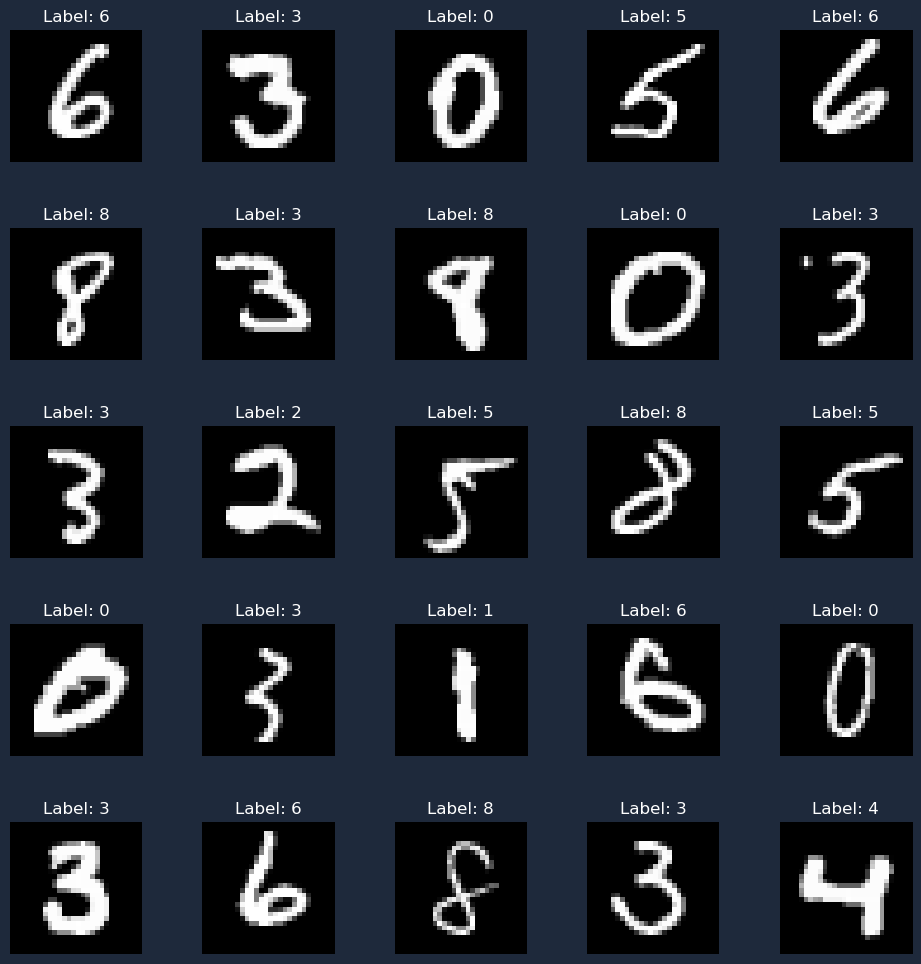

In [28]:
# Plot a grid of 25 random training images
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.ravel()

for i in range(25):
    # Select a random image
    idx = np.random.randint(0, X_train.shape[0])
    image = X_train[idx].reshape(28, 28)
    
    # Plot the image
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {int(y_train[idx])}", color='white')
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.5)
fig.patch.set_facecolor('#1e293b')
plt.show()

In [29]:
def pairwise_distances(x, y):
    """
    Calculates the pairwise squared Euclidean distances between two sets of vectors.
    
    Args:
        x (torch.Tensor): A tensor of shape (N, D), where N is the number of vectors in the first set.
        y (torch.Tensor): A tensor of shape (M, D), where M is the number of vectors in the second set.
        
    Returns:
        torch.Tensor: A tensor of shape (N, M) containing the squared distances.
    """
    # Calculate the squared L2 norm of each vector in x
    x_norm = (x**2).sum(1).view(-1, 1)
    
    # Transpose y for matrix multiplication
    y_t = torch.transpose(y, 0, 1)
    
    # Calculate the squared L2 norm of each vector in y
    y_norm = (y**2).sum(1).view(1, -1)
    
    # The core calculation: x_norm + y_norm - 2 * (x @ y_t)
    dist = x_norm + y_norm - 2.0 * torch.mm(x, y_t)
    
    # Clamp the distances to be non-negative to handle potential floating-point inaccuracies
    return torch.clamp(dist, 0.0, np.inf)

In [30]:
%%time

# Move training and test data to the selected device (MPS/CUDA/CPU)
device_train = torch.from_numpy(X_train).to(device).float()
device_test = torch.from_numpy(X_test).to(device).float()

# Create a PyTorch dataset and dataloader for the test data
ds = torch.utils.data.TensorDataset(device_test)
bs = 1000 # Batch size
data_loader = torch.utils.data.DataLoader(ds, batch_size=bs, pin_memory=False)

# Lists to store the results from each batch
_min_dists = []
_arg_min_dists = []

print(f"Processing {len(device_test)} test images in batches of {bs}...")

for i, (batch,) in enumerate(data_loader):
    # Calculate distances from all training images to the current batch of test images
    distances = pairwise_distances(device_train, batch)
    
    # Find the minimum distance and the index of the nearest neighbor for each test image in the batch
    min_dist, arg_min_dist = distances.min(0)
    
    # Append the results
    _min_dists.append(min_dist)
    _arg_min_dists.append(arg_min_dist)
    print(f"  Processed batch {i+1}/{len(data_loader)}")

print("...Processing complete.")

Processing 28000 test images in batches of 1000...
  Processed batch 1/28
  Processed batch 2/28
  Processed batch 3/28
  Processed batch 4/28
  Processed batch 5/28
  Processed batch 6/28
  Processed batch 7/28
  Processed batch 8/28
  Processed batch 9/28
  Processed batch 10/28
  Processed batch 11/28
  Processed batch 12/28
  Processed batch 13/28
  Processed batch 14/28
  Processed batch 15/28
  Processed batch 16/28
  Processed batch 17/28
  Processed batch 18/28
  Processed batch 19/28
  Processed batch 20/28
  Processed batch 21/28
  Processed batch 22/28
  Processed batch 23/28
  Processed batch 24/28
  Processed batch 25/28
  Processed batch 26/28
  Processed batch 27/28
  Processed batch 28/28
...Processing complete.
CPU times: user 218 ms, sys: 50.1 ms, total: 268 ms
Wall time: 473 ms


In [31]:
# Concatenate the lists of results into single tensors
min_dists = torch.cat(_min_dists)
arg_min_dists = torch.cat(_arg_min_dists)

# Check how many test samples were not found as exact matches in the training set
not_found_count = len(min_dists[min_dists > 0])
print(f'Number of not found samples (distance > 0): {not_found_count}')

Number of not found samples (distance > 0): 3


In [32]:
# Create a dummy sample submission if not found
try:
    sub = pd.read_csv('../input/digit-recognizer/sample_submission.csv')
except FileNotFoundError:
    print("Sample submission not found. Creating a dummy one.")
    sub = pd.DataFrame({'ImageId': range(1, len(X_test) + 1), 'Label': 0})


# Get the predicted labels by indexing y_train with our results
# We need to move the indices from the GPU to the CPU first with .cpu()
predicted_labels = y_train[arg_min_dists.cpu()]

# Assign the predicted labels to the submission DataFrame
sub['Label'] = predicted_labels

# Save the submission file
sub.to_csv('submission.csv', index=False)

# Print the first few lines of our submission file
print("Submission file created successfully!")
print("Head of submission.csv:")
print(sub.head())

Sample submission not found. Creating a dummy one.
Submission file created successfully!
Head of submission.csv:
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3


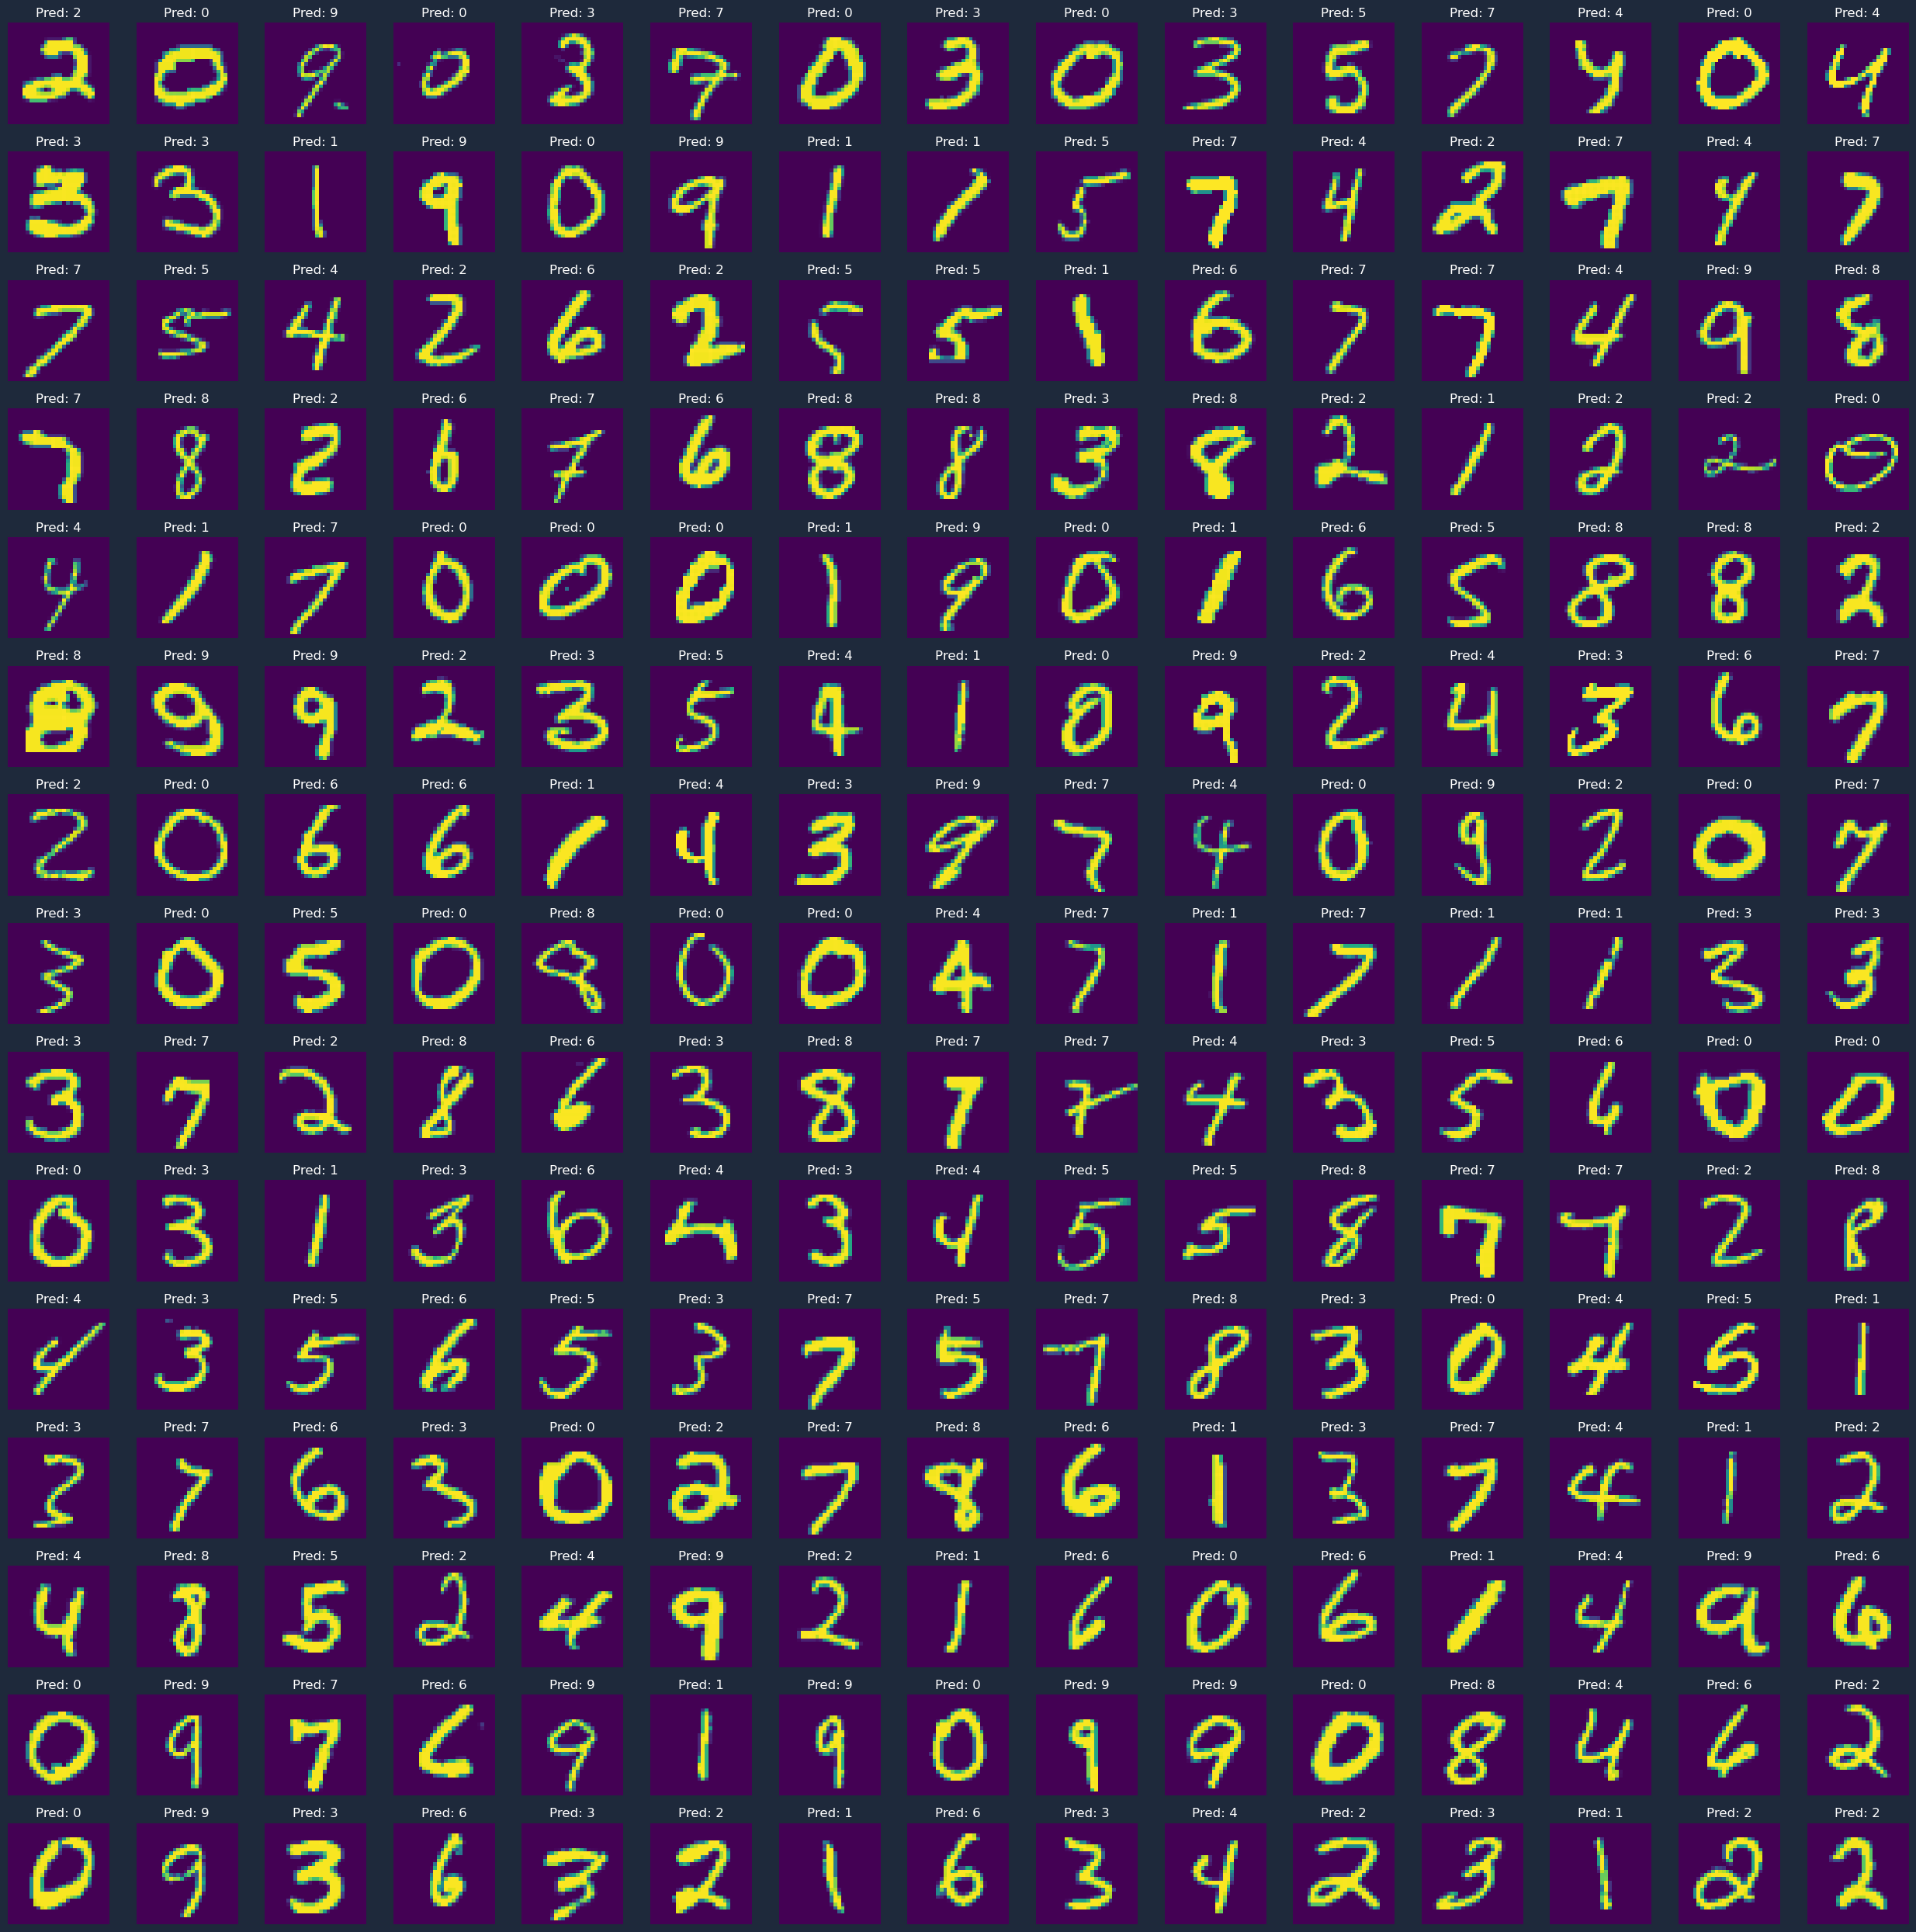

In [33]:
# Visualize the first 225 predictions
fig, axs = plt.subplots(15, 15, figsize=(25, 25))

for i, ax in enumerate(axs.flatten()):
    if i < len(sub):
        # Set the title to our predicted label
        ax.set_title(f"Pred: {sub.Label[i]}", color='white', fontsize=12)
        
        # Display the test image
        ax.imshow(X_test[i].reshape(28, 28), cmap='viridis')
        
        # Turn off axis ticks and labels
        ax.axis('off')

fig.patch.set_facecolor('#1e293b')
plt.tight_layout()
plt.show()